# Credit Card 数据集全量变量分箱对比实验

本 Notebook 对 `creditcard.csv` 数据集的**所有变量**进行分箱，对比 `scorecard` 模块和 `scorecard_legacy` 模块的分箱结果。

## 数据集说明
- creditcard.csv 是信用卡欺诈检测数据集
- 目标变量：Class (0=正常, 1=欺诈)
- 特征：Time, V1-V28 (PCA降维后的特征), Amount (交易金额)
- 共 30 个特征，约 28 万条记录

In [1]:
# 设置内核为 conda py311 环境
# 请确保在 Jupyter 中选择正确的内核: Python (py311)

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import time
from IPython.display import display, HTML

print(f"Python 版本: {sys.version}")
print(f"Pandas 版本: {pd.__version__}")
print(f"NumPy 版本: {np.__version__}")

Python 版本: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]
Pandas 版本: 3.0.1
NumPy 版本: 1.26.0


## 1. 加载数据

In [3]:
# 加载 creditcard 数据集
df = pd.read_csv('../data/creditcard.csv.gz')
print(f"数据集形状: {df.shape}")
print(f"\n目标变量分布:")
print(df['Class'].value_counts())
print(f"\n坏率: {df['Class'].mean():.4%}")

数据集形状: (284807, 31)

目标变量分布:
Class
0    284315
1       492
Name: count, dtype: int64

坏率: 0.1727%


In [4]:
# 确定所有特征变量
target = 'Class'
all_features = [col for col in df.columns if col != target]

print(f"目标变量: {target}")
print(f"特征数量: {len(all_features)}")
print(f"特征列表: {all_features}")

目标变量: Class
特征数量: 30
特征列表: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 2. 使用 scorecard_legacy 模块进行分箱

In [5]:
from syriskmodels.scorecard_legacy import woebin as woebin_legacy
from syriskmodels.scorecard_legacy import sc_bins_to_df as sc_bins_to_df_legacy

In [6]:
%%time
# 使用 scorecard_legacy 进行分箱
# 默认方法: quantile + tree
# 使用多进程加速
print("开始 scorecard_legacy 分箱...")
start_time = time.time()

bins_legacy = woebin_legacy(
    df, 
    y=target, 
    x=all_features,
    methods=['quantile', 'tree'],
    no_cores=4  # 使用4个进程加速
)

legacy_time = time.time() - start_time
print(f"\nscorecard_legacy 分箱耗时: {legacy_time:.2f} 秒")

开始 scorecard_legacy 分箱...

scorecard_legacy 分箱耗时: 4.63 秒
CPU times: user 150 ms, sys: 287 ms, total: 438 ms
Wall time: 4.63 s


In [7]:
# 查看分箱结果
woe_df_legacy, iv_df_legacy = sc_bins_to_df_legacy(bins_legacy)
print("=== scorecard_legacy 分箱结果 ===")
print(f"\n成功分箱变量数: {len([v for v in bins_legacy if isinstance(bins_legacy[v], pd.DataFrame)])}")
print(f"\nIV 汇总表 (按 IV 降序):")
display(iv_df_legacy)

=== scorecard_legacy 分箱结果 ===

成功分箱变量数: 30

IV 汇总表 (按 IV 降序):


,IV,IV区间,单调性,最大Lift,最小Lift
variable,,,,,
V14,4.183796,"[0.2, +)",decreasing,17.675914,0.121954
V12,3.772570,"[0.2, +)",decreasing,16.491731,0.081301
V4,3.735624,"[0.2, +)",increasing,14.433276,0.020325
V10,3.682150,"[0.2, +)",decreasing,16.847429,0.166871
V17,3.494484,"[0.2, +)",up_u_shape,15.202558,0.102983
V11,3.208620,"[0.2, +)",increasing,15.851822,0.218230
V3,3.056649,"[0.2, +)",decreasing,14.762680,0.137583
V16,2.728747,"[0.2, +)",decreasing,14.682375,0.280266
V7,2.520738,"[0.2, +)",decreasing,14.095150,0.310239


## 3. 使用 scorecard 模块进行分箱

In [8]:
from syriskmodels.scorecard import woebin as woebin_new
from syriskmodels.scorecard import sc_bins_to_df as sc_bins_to_df_new

In [9]:
%%time
# 使用 scorecard 模块进行分箱
# 相同的参数设置
print("开始 scorecard 模块分箱...")
start_time = time.time()

bins_new = woebin_new(
    df, 
    y=target, 
    x=all_features,
    methods=['quantile', 'tree'],
    no_cores=4
)

new_time = time.time() - start_time
print(f"\nscorecard 模块分箱耗时: {new_time:.2f} 秒")

开始 scorecard 模块分箱...

scorecard 模块分箱耗时: 4.14 秒
CPU times: user 104 ms, sys: 243 ms, total: 346 ms
Wall time: 4.14 s


In [10]:
# 查看分箱结果
woe_df_new, iv_df_new = sc_bins_to_df_new(bins_new)
print("=== scorecard 模块分箱结果 ===")
print(f"\n成功分箱变量数: {len([v for v in bins_new if isinstance(bins_new[v], pd.DataFrame)])}")
print(f"\nIV 汇总表 (按 IV 降序):")
display(iv_df_new)

=== scorecard 模块分箱结果 ===

成功分箱变量数: 30

IV 汇总表 (按 IV 降序):


,IV,IV区间,单调性,最大Lift,最小Lift
variable,,,,,
V14,4.183796,"[0.2, +)",decreasing,17.675914,0.121954
V12,3.772570,"[0.2, +)",decreasing,16.491731,0.081301
V4,3.735624,"[0.2, +)",increasing,14.433276,0.020325
V10,3.682150,"[0.2, +)",decreasing,16.847429,0.166871
V17,3.494484,"[0.2, +)",up_u_shape,15.202558,0.102983
V11,3.208620,"[0.2, +)",increasing,15.851822,0.218230
V3,3.056649,"[0.2, +)",decreasing,14.762680,0.137583
V16,2.728747,"[0.2, +)",decreasing,14.682375,0.280266
V7,2.520738,"[0.2, +)",decreasing,14.095150,0.310239


## 4. 分箱结果全面对比

### 4.1 性能对比

In [11]:
print("="*60)
print("性能对比")
print("="*60)
print(f"\nscorecard_legacy 耗时: {legacy_time:.2f} 秒")
print(f"scorecard 模块耗时:   {new_time:.2f} 秒")
print(f"\n性能差异: {(new_time - legacy_time):.2f} 秒 ({(new_time/legacy_time - 1)*100:+.1f}%)")

性能对比

scorecard_legacy 耗时: 4.63 秒
scorecard 模块耗时:   4.14 秒

性能差异: -0.49 秒 (-10.6%)


### 4.2 IV 值对比

In [12]:
# IV 值对比
iv_compare = pd.DataFrame({
    'variable': iv_df_legacy.index,
    'IV_legacy': iv_df_legacy['IV'].values,
    'IV_new': iv_df_new['IV'].values,
})
iv_compare['IV_diff'] = (iv_compare['IV_new'] - iv_compare['IV_legacy']).abs()
iv_compare['IV_diff_pct'] = np.where(
    iv_compare['IV_legacy'] > 0,
    iv_compare['IV_diff'] / iv_compare['IV_legacy'] * 100,
    0
)

print("IV 值对比 (按 legacy IV 降序):")
display(iv_compare.round(6))

IV 值对比 (按 legacy IV 降序):


,variable,IV_legacy,IV_new,IV_diff,IV_diff_pct
0,V14,4.183796,4.183796,0.0,0.0
1,V12,3.772570,3.772570,0.0,0.0
2,V4,3.735624,3.735624,0.0,0.0
3,V10,3.682150,3.682150,0.0,0.0
4,V17,3.494484,3.494484,0.0,0.0
5,V11,3.208620,3.208620,0.0,0.0
6,V3,3.056649,3.056649,0.0,0.0
7,V16,2.728747,2.728747,0.0,0.0
8,V7,2.520738,2.520738,0.0,0.0
9,V2,2.346762,2.346762,0.0,0.0


In [13]:
# IV 差异统计
print("\nIV 差异统计:")
print(f"  - 平均差异: {iv_compare['IV_diff'].mean():.6f}")
print(f"  - 最大差异: {iv_compare['IV_diff'].max():.6f}")
print(f"  - 差异 > 0.001 的变量数: {(iv_compare['IV_diff'] > 0.001).sum()}")
print(f"  - 差异 > 0.01 的变量数: {(iv_compare['IV_diff'] > 0.01).sum()}")


IV 差异统计:
  - 平均差异: 0.000000
  - 最大差异: 0.000000
  - 差异 > 0.001 的变量数: 0
  - 差异 > 0.01 的变量数: 0


### 4.3 分箱数量对比

In [14]:
# 分箱数量对比
bin_count_data = []
for var in all_features:
    legacy_count = len(bins_legacy[var]) if isinstance(bins_legacy[var], pd.DataFrame) else 0
    new_count = len(bins_new[var]) if isinstance(bins_new[var], pd.DataFrame) else 0
    bin_count_data.append({
        'variable': var,
        'bins_legacy': legacy_count,
        'bins_new': new_count,
        'bins_diff': new_count - legacy_count
    })

bin_count_compare = pd.DataFrame(bin_count_data)

print("分箱数量对比:")
display(bin_count_compare)

分箱数量对比:


,variable,bins_legacy,bins_new,bins_diff
0,Time,6,6,0
1,V1,4,4,0
2,V2,3,3,0
3,V3,3,3,0
4,V4,4,4,0
5,V5,2,2,0
6,V6,2,2,0
7,V7,2,2,0
8,V8,4,4,0
9,V9,3,3,0


In [15]:
# 分箱数量统计
print("\n分箱数量统计:")
print(f"  - legacy 总分箱数: {bin_count_compare['bins_legacy'].sum()}")
print(f"  - new 总分箱数: {bin_count_compare['bins_new'].sum()}")
print(f"  - 分箱数完全一致的变量数: {(bin_count_compare['bins_diff'] == 0).sum()}")
print(f"  - 分箱数不一致的变量数: {(bin_count_compare['bins_diff'] != 0).sum()}")


分箱数量统计:
  - legacy 总分箱数: 114
  - new 总分箱数: 114
  - 分箱数完全一致的变量数: 30
  - 分箱数不一致的变量数: 0


### 4.4 切分点详细对比

In [16]:
def compare_var_breaks(bins_legacy, bins_new, var_name):
    """对比单个变量的切分点，返回对比结果"""
    if not isinstance(bins_legacy[var_name], pd.DataFrame) or not isinstance(bins_new[var_name], pd.DataFrame):
        return None
    
    # 提取切分点（非特殊值）
    breaks_legacy = bins_legacy[var_name][~bins_legacy[var_name]['is_special_values']]['breaks'].tolist()
    breaks_new = bins_new[var_name][~bins_new[var_name]['is_special_values']]['breaks'].tolist()
    
    # 检查是否一致
    is_same = set(breaks_legacy) == set(breaks_new)
    
    return {
        'variable': var_name,
        'breaks_legacy': breaks_legacy,
        'breaks_new': breaks_new,
        'is_same': is_same,
        'n_legacy': len(breaks_legacy),
        'n_new': len(breaks_new)
    }

# 对比所有变量
breaks_comparison = []
for var in all_features:
    result = compare_var_breaks(bins_legacy, bins_new, var)
    if result:
        breaks_comparison.append(result)

breaks_df = pd.DataFrame(breaks_comparison)
print("切分点一致性检查:")
print(f"  - 切分点完全一致的变量数: {breaks_df['is_same'].sum()}")
print(f"  - 切分点不一致的变量数: {(~breaks_df['is_same']).sum()}")

切分点一致性检查:
  - 切分点完全一致的变量数: 30
  - 切分点不一致的变量数: 0


In [17]:
# 显示切分点不一致的变量详情
diff_vars = breaks_df[~breaks_df['is_same']]
if len(diff_vars) > 0:
    print("\n切分点不一致的变量详情:")
    for _, row in diff_vars.iterrows():
        print(f"\n{row['variable']}:")
        print(f"  legacy ({row['n_legacy']}): {row['breaks_legacy']}")
        print(f"  new ({row['n_new']}): {row['breaks_new']}")
else:
    print("\n✓ 所有变量的切分点完全一致！")


✓ 所有变量的切分点完全一致！


### 4.5 WOE 值差异分析

In [18]:
# 计算每个变量的 WOE 最大差异
woe_diff_data = []

for var in all_features:
    if not isinstance(bins_legacy[var], pd.DataFrame) or not isinstance(bins_new[var], pd.DataFrame):
        continue
    
    # 合并两个分箱结果进行对比
    legacy_woe = bins_legacy[var][['bin', 'woe']].copy()
    legacy_woe.columns = ['bin', 'woe_legacy']
    
    new_woe = bins_new[var][['bin', 'woe']].copy()
    new_woe.columns = ['bin', 'woe_new']
    
    merged = pd.merge(legacy_woe, new_woe, on='bin', how='outer')
    merged['woe_diff'] = (merged['woe_legacy'] - merged['woe_new']).abs()
    
    woe_diff_data.append({
        'variable': var,
        'max_woe_diff': merged['woe_diff'].max(),
        'mean_woe_diff': merged['woe_diff'].mean()
    })

woe_diff_df = pd.DataFrame(woe_diff_data)
woe_diff_df = woe_diff_df.sort_values('max_woe_diff', ascending=False)

print("WOE 值差异分析 (按最大差异降序):")
display(woe_diff_df.round(6))

WOE 值差异分析 (按最大差异降序):


,variable,max_woe_diff,mean_woe_diff
0,Time,0.0,0.0
1,V1,0.0,0.0
28,V28,0.0,0.0
27,V27,0.0,0.0
26,V26,0.0,0.0
25,V25,0.0,0.0
24,V24,0.0,0.0
23,V23,0.0,0.0
22,V22,0.0,0.0
21,V21,0.0,0.0


In [19]:
# WOE 差异统计
print("\nWOE 差异统计:")
print(f"  - 平均最大差异: {woe_diff_df['max_woe_diff'].mean():.6f}")
print(f"  - 最大差异: {woe_diff_df['max_woe_diff'].max():.6f}")
print(f"  - 最大差异 > 0.01 的变量数: {(woe_diff_df['max_woe_diff'] > 0.01).sum()}")
print(f"  - 最大差异 > 0.1 的变量数: {(woe_diff_df['max_woe_diff'] > 0.1).sum()}")


WOE 差异统计:
  - 平均最大差异: 0.000000
  - 最大差异: 0.000000
  - 最大差异 > 0.01 的变量数: 0
  - 最大差异 > 0.1 的变量数: 0


## 5. 详细分箱结果对比（选取 IV 前5的变量）

In [20]:
# 选取 IV 前5的变量进行详细对比
top_vars = iv_df_legacy.head(5).index.tolist()
print(f"IV 前5变量: {top_vars}")

for var in top_vars:
    print(f"\n{'='*60}")
    print(f"变量: {var}")
    print('='*60)
    
    # legacy 结果
    print("\nscorecard_legacy 分箱:")
    display(bins_legacy[var][['variable', 'bin', 'count', 'count_distr', 'badprob', 'woe', 'bin_iv', 'total_iv']].round(4))
    
    # new 结果
    print("\nscorecard 模块分箱:")
    display(bins_new[var][['variable', 'bin', 'count', 'count_distr', 'badprob', 'woe', 'bin_iv', 'total_iv']].round(4))

IV 前5变量: ['V14', 'V12', 'V4', 'V10', 'V17']

变量: V14

scorecard_legacy 分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,V14,"[-inf,-1.439)",14246,0.05,0.0305,-2.9015,2.4244,4.1838
1,V14,"[-1.439,inf)",270561,0.95,0.0002,2.1056,1.7594,4.1838



scorecard 模块分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,V14,"[-inf,-1.439)",14246,0.05,0.0305,-2.9015,2.4244,4.1838
1,V14,"[-1.439,inf)",270561,0.95,0.0002,2.1056,1.7594,4.1838



变量: V12

scorecard_legacy 分箱:


...

,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,V10,"[-inf,-1.339)",14225,0.0499,0.0291,-2.852,2.2613,3.6822
1,V10,"[-1.339,inf)",270582,0.9501,0.0003,1.792,1.4208,3.6822



变量: V17

scorecard_legacy 分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,V17,"[-inf,-0.983)",14241,0.05,0.0263,-2.7463,1.9537,3.4945
1,V17,"[-0.983,0.5189)",213602,0.75,0.0002,2.2747,1.5330,3.4945
2,V17,"[0.5189,inf)",56964,0.20,0.0014,0.2074,0.0078,3.4945



scorecard 模块分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,V17,"[-inf,-0.983)",14241,0.05,0.0263,-2.7463,1.9537,3.4945
1,V17,"[-0.983,0.5189)",213602,0.75,0.0002,2.2747,1.5330,3.4945
2,V17,"[0.5189,inf)",56964,0.20,0.0014,0.2074,0.0078,3.4945


## 6. 可视化对比

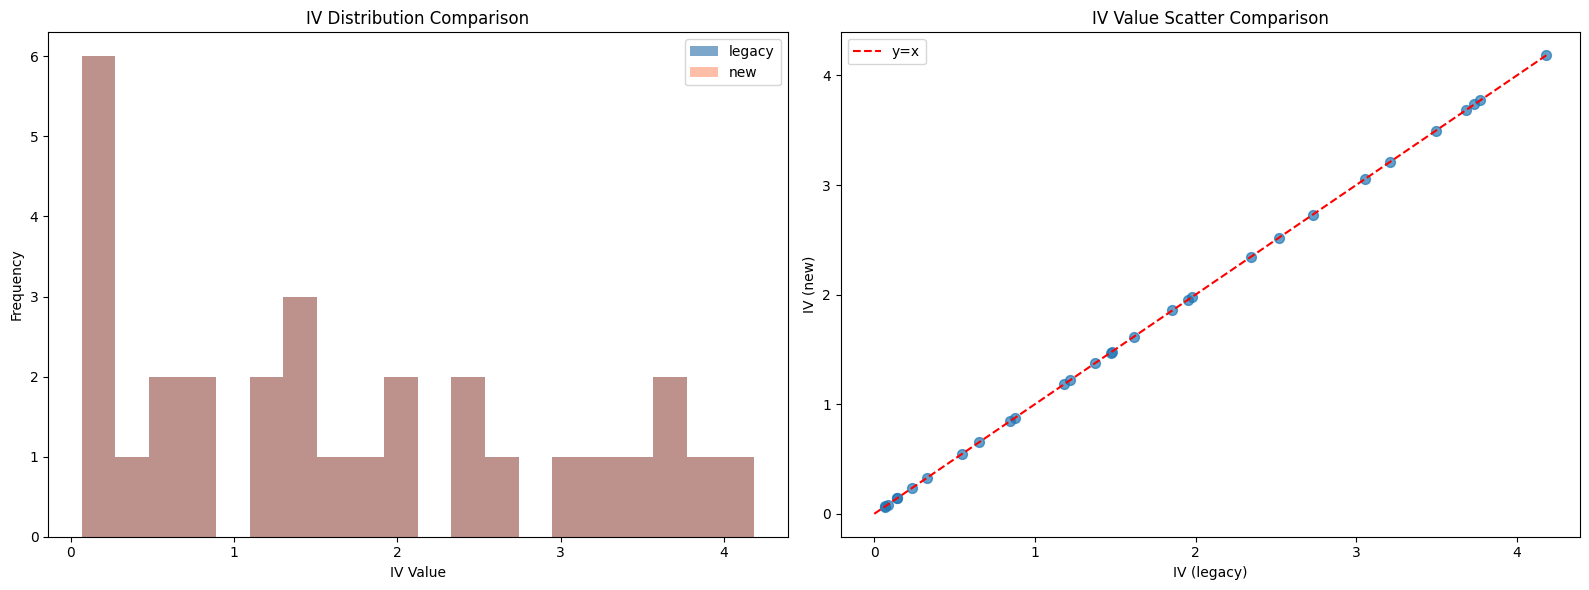

In [21]:
import matplotlib.pyplot as plt

def plot_iv_comparison(iv_df_legacy, iv_df_new):
    """绘制 IV 值对比图"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # IV 分布直方图
    ax1 = axes[0]
    ax1.hist(iv_df_legacy['IV'], bins=20, alpha=0.7, label='legacy', color='steelblue')
    ax1.hist(iv_df_new['IV'], bins=20, alpha=0.5, label='new', color='coral')
    ax1.set_xlabel('IV Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title('IV Distribution Comparison')
    ax1.legend()
    
    # IV 散点对比图
    ax2 = axes[1]
    ax2.scatter(iv_df_legacy['IV'], iv_df_new['IV'], alpha=0.7, s=50)
    max_iv = max(iv_df_legacy['IV'].max(), iv_df_new['IV'].max())
    ax2.plot([0, max_iv], [0, max_iv], 'r--', label='y=x')
    ax2.set_xlabel('IV (legacy)')
    ax2.set_ylabel('IV (new)')
    ax2.set_title('IV Value Scatter Comparison')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_iv_comparison(iv_df_legacy, iv_df_new)

Top 6 变量 WOE 曲线对比:


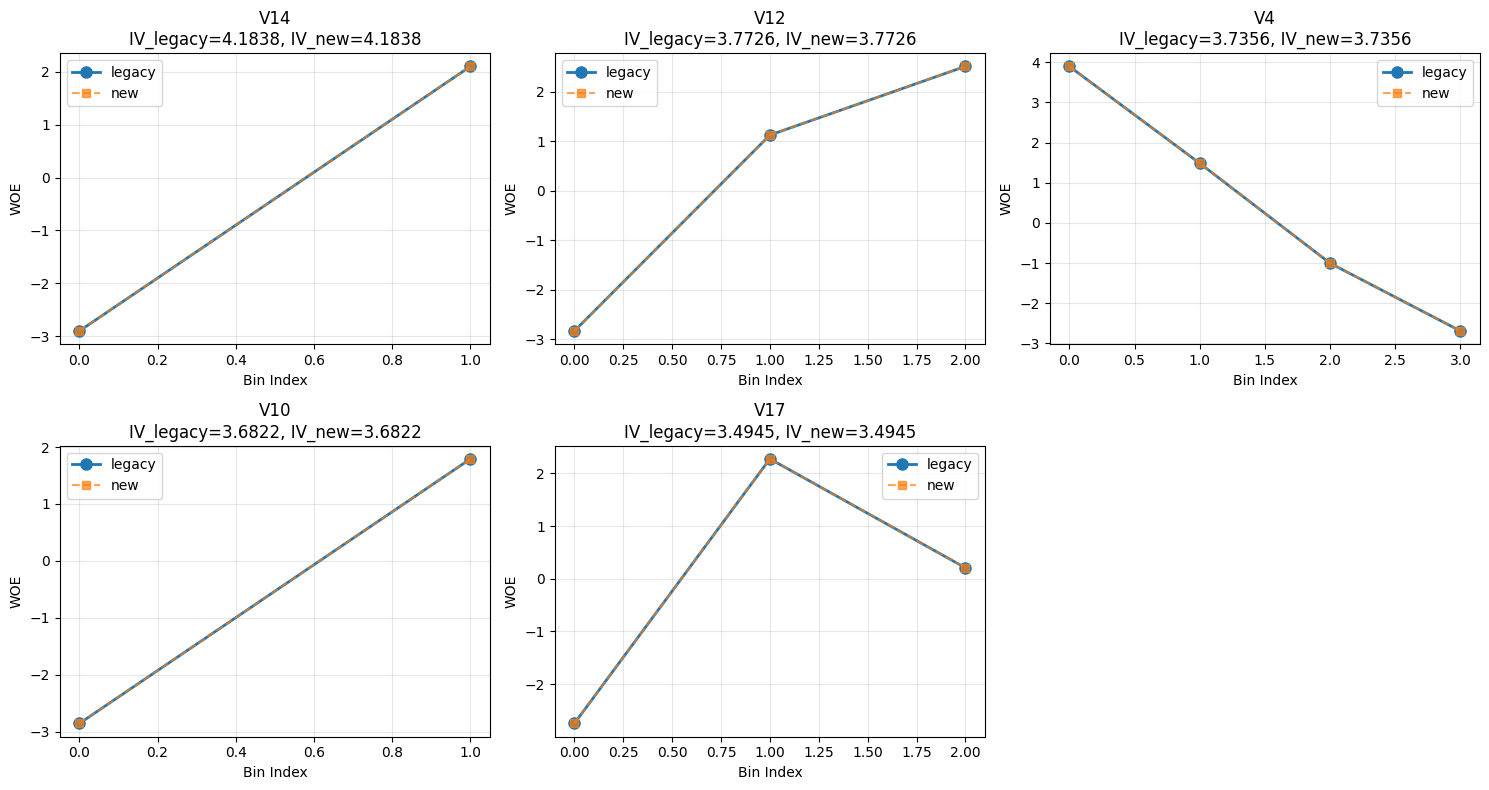

In [22]:
def plot_top_vars_woe(bins_legacy, bins_new, top_vars, n_cols=3):
    """绘制 Top 变量的 WOE 对比图"""
    n_vars = len(top_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for idx, var in enumerate(top_vars):
        ax = axes[idx]
        
        # legacy
        df_leg = bins_legacy[var][~bins_legacy[var]['is_special_values']].copy()
        # new
        df_new = bins_new[var][~bins_new[var]['is_special_values']].copy()
        
        x_legacy = range(len(df_leg))
        x_new = range(len(df_new))
        
        ax.plot(x_legacy, df_leg['woe'].values, 'o-', label='legacy', markersize=8, linewidth=2)
        ax.plot(x_new, df_new['woe'].values, 's--', label='new', markersize=6, linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Bin Index')
        ax.set_ylabel('WOE')
        ax.set_title(f'{var}\nIV_legacy={df_leg["total_iv"].iloc[0]:.4f}, IV_new={df_new["total_iv"].iloc[0]:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    for idx in range(len(top_vars), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("Top 6 变量 WOE 曲线对比:")
plot_top_vars_woe(bins_legacy, bins_new, top_vars[:6])

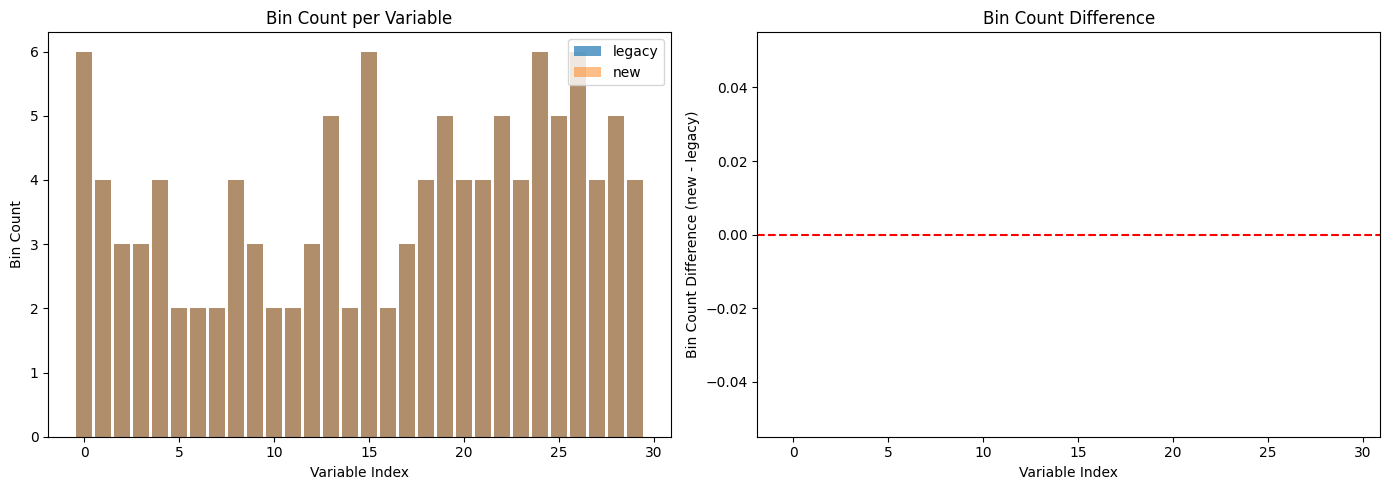

In [23]:
# 分箱数量分布对比
def plot_bin_count_comparison(bin_count_compare):
    """绘制分箱数量对比"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 分箱数量分布
    ax1 = axes[0]
    ax1.bar(range(len(bin_count_compare)), bin_count_compare['bins_legacy'], alpha=0.7, label='legacy')
    ax1.bar(range(len(bin_count_compare)), bin_count_compare['bins_new'], alpha=0.5, label='new')
    ax1.set_xlabel('Variable Index')
    ax1.set_ylabel('Bin Count')
    ax1.set_title('Bin Count per Variable')
    ax1.legend()
    
    # 分箱数量差异
    ax2 = axes[1]
    ax2.bar(range(len(bin_count_compare)), bin_count_compare['bins_diff'])
    ax2.axhline(y=0, color='r', linestyle='--')
    ax2.set_xlabel('Variable Index')
    ax2.set_ylabel('Bin Count Difference (new - legacy)')
    ax2.set_title('Bin Count Difference')
    
    plt.tight_layout()
    plt.show()

plot_bin_count_comparison(bin_count_compare)

## 7. 总结

In [24]:
print("="*70)
print(" "*20 + "全量变量分箱对比总结")
print("="*70)

print(f"\n数据集: creditcard.csv")
print(f"样本数: {len(df):,}")
print(f"特征数: {len(all_features)}")

print("\n" + "-"*70)
print("1. 性能对比")
print("-"*70)
print(f"   scorecard_legacy 耗时: {legacy_time:.2f} 秒")
print(f"   scorecard 模块耗时:   {new_time:.2f} 秒")
print(f"   性能差异: {(new_time - legacy_time):.2f} 秒 ({(new_time/legacy_time - 1)*100:+.1f}%)")

print("\n" + "-"*70)
print("2. IV 值对比")
print("-"*70)
print(f"   平均差异: {iv_compare['IV_diff'].mean():.6f}")
print(f"   最大差异: {iv_compare['IV_diff'].max():.6f}")
print(f"   差异 > 0.001 的变量数: {(iv_compare['IV_diff'] > 0.001).sum()} / {len(all_features)}")
print(f"   差异 > 0.01 的变量数: {(iv_compare['IV_diff'] > 0.01).sum()} / {len(all_features)}")

print("\n" + "-"*70)
print("3. 分箱数量对比")
print("-"*70)
print(f"   legacy 总分箱数: {bin_count_compare['bins_legacy'].sum()}")
print(f"   new 总分箱数: {bin_count_compare['bins_new'].sum()}")
print(f"   分箱数完全一致的变量: {(bin_count_compare['bins_diff'] == 0).sum()} / {len(all_features)}")

print("\n" + "-"*70)
print("4. 切分点对比")
print("-"*70)
print(f"   切分点完全一致的变量: {breaks_df['is_same'].sum()} / {len(all_features)}")

print("\n" + "-"*70)
print("5. WOE 值对比")
print("-"*70)
print(f"   平均最大差异: {woe_diff_df['max_woe_diff'].mean():.6f}")
print(f"   最大差异: {woe_diff_df['max_woe_diff'].max():.6f}")

print("\n" + "-"*70)
print("6. 结论")
print("-"*70)
if iv_compare['IV_diff'].max() < 0.01:
    print("   ✓ scorecard 模块与 scorecard_legacy 模块分箱结果高度一致")
    print("   ✓ 两个模块可以互换使用，结果差异在可接受范围内")
else:
    print("   ⚠ 两个模块分箱结果存在一定差异，需要进一步检查")
    print("   ⚠ 建议查看差异较大的变量的分箱详情")

print("\n" + "-"*70)
print("7. 模块特点")
print("-"*70)
print("   scorecard_legacy:")
print("     - 单文件实现，包含完整分箱逻辑")
print("     - 适合快速原型开发")
print("\n   scorecard:")
print("     - 模块化设计，更好的代码组织")
print("     - 更好的扩展性和可维护性")
print("     - 推荐用于生产环境")

                    全量变量分箱对比总结

数据集: creditcard.csv
样本数: 284,807
特征数: 30

----------------------------------------------------------------------
1. 性能对比
----------------------------------------------------------------------
   scorecard_legacy 耗时: 4.63 秒
   scorecard 模块耗时:   4.14 秒
   性能差异: -0.49 秒 (-10.6%)

----------------------------------------------------------------------
2. IV 值对比
----------------------------------------------------------------------
   平均差异: 0.000000
   最大差异: 0.000000
   差异 > 0.001 的变量数: 0 / 30
   差异 > 0.01 的变量数: 0 / 30

----------------------------------------------------------------------
3. 分箱数量对比
----------------------------------------------------------------------
   legacy 总分箱数: 114
   new 总分箱数: 114
   分箱数完全一致的变量: 30 / 30

----------------------------------------------------------------------
4. 切分点对比
----------------------------------------------------------------------
   切分点完全一致的变量: 30 / 30

------------------------------------------------------------